In [9]:
!pip install hdbscan umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 10.1 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 10.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.3 MB/s  0:00:05m0:00:0100:01
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Created wheel for hdbscan: filename=hdbscan-0.8.40-cp312-cp312-linux_x86_64.whl size=4185982 sha256=0586c3403513ff7b084f04a4c368edcb3adf84163bc7d52b9dd0c3549d2d1ecb
  Stored in directory: /home/hasinthaka/.cache/pip/wheels/80/e7/bb/173ca0d8ce12718c4b5e6e01619c99653579b56969b97604b2
Successfully built hdbscan
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [umap-learn]6 [umap-learn]]


In [1]:
import pandas as pd
from sklearn.cluster import KMeans,DBSCAN
from hdbscan import HDBSCAN


In [2]:
data = pd.read_csv("../outputs/[25.10.23] - 03 - Optimized prompts/pattern_embeddings.csv")

In [3]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Pattern Name
0,-0.014887,0.011846,0.024592,-0.067006,0.005267,-0.013206,-0.001700,0.005825,0.011101,-0.002746,...,-0.002264,-0.004080,-0.016984,0.020781,0.013339,-0.017017,-0.016860,-0.009608,0.009370,Tool-Augmented Foundation Model
1,-0.014603,0.015495,0.013889,-0.074237,-0.013952,-0.001392,-0.016772,0.013229,0.013748,0.004512,...,-0.002935,0.001175,-0.001461,0.018538,0.002541,-0.019309,-0.025976,-0.013837,-0.002050,Controller-Perceiver Architecture
2,-0.015710,0.018816,0.017640,-0.062721,0.001514,-0.012712,-0.025657,0.039852,0.003625,-0.006140,...,-0.000852,0.001590,-0.008123,0.009664,0.007908,-0.021545,-0.023862,-0.000275,-0.004483,Intent and Tool Understanding
3,-0.003433,0.025213,0.028919,-0.061162,-0.003288,-0.013924,-0.024160,0.022861,0.002362,-0.002605,...,0.001578,-0.003536,-0.015283,0.018430,0.005692,-0.020411,-0.016935,0.006562,-0.002777,Zero-shot Prompting for Tool Understanding
4,-0.009638,0.022001,0.032741,-0.064794,-0.000068,-0.018295,-0.019508,0.028052,-0.001001,0.000767,...,0.001119,-0.002180,-0.010505,0.022138,0.010829,-0.022627,-0.019131,0.001625,-0.001408,Few-shot Prompting for Tool Understanding


In [4]:
embeddings = data.drop(labels=["Pattern Name"],axis=1)

### Checking Distance

In [5]:
from sklearn.metrics import pairwise_distances
import numpy as np

distances = pairwise_distances(embeddings)
print("Min distance:", distances.min())
print("Max distance:", distances.max())
print("Mean distance:", distances.mean())

Min distance: 0.0
Max distance: 0.7868439245268284
Mean distance: 0.590601969079839


## KMeans Clustering

In [6]:
num_clusters = 50
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings)


## DBSCAN Clustering

In [31]:
from pandas import DataFrame


dbscan = DBSCAN(eps=0.05,min_samples=1, metric='cosine')
labels = dbscan.fit_predict(embeddings)
len(set(labels.tolist()))

403

In [7]:
dbscan = HDBSCAN(min_cluster_size=2, metric='euclidean')
labels = dbscan.fit_predict(embeddings)
labels

/home/hasinthaka/Documents/Projects/AI/AI Pattern Mining/Paper Mining/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/hasinthaka/Documents/Projects/AI/AI Pattern Mining/Paper Mining/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([-1, -1, 21, 21, 21, -1, -1, 21, 22, -1, -1, -1, -1, -1, -1, 23, -1,
       -1, -1, -1, 41, -1, 22, -1, -1, -1, -1, -1, -1, 39, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 22,
       -1, 22, 22, -1, 22, 22, -1, -1, -1, 39, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, 40, -1, -1, 37, 30, 38, -1,  4,  4,  4,
        4, -1,  4, -1, -1, -1, -1,  4,  4, -1,  4, -1, -1, -1,  4, -1, -1,
       29, -1, 34, 34, -1, -1, -1, -1, -1, 29, 12, 12, -1, 39, 19, 19, 26,
       26, -1, -1, -1, 15, 15, 15, 14, 20, 20, -1, -1,  7,  8, -1,  8,  5,
       -1, -1, -1,  5, -1,  1, -1, -1, -1, -1,  6,  2, -1, -1, -1, -1, -1,
        7,  1, -1, -1,  6, -1, -1, -1, -1, -1,  2, -1,  5,  7,  0,  0, 17,
       -1, 17, -1, -1, -1, -1, 22, -1, 39, -1, -1, 29, -1, -1, 33, -1, -1,
       -1, -1, -1,  3, -1,  3, 39, -1, -1, -1, -1, -1, -1, 41, 31, -1, -1,
       -1, -1, -1, -1, -1, -1, 23, -1, 11, 11, -1, 30, -1, -1, -1, 14, 13,
       -1, 13, -1, -1, 13

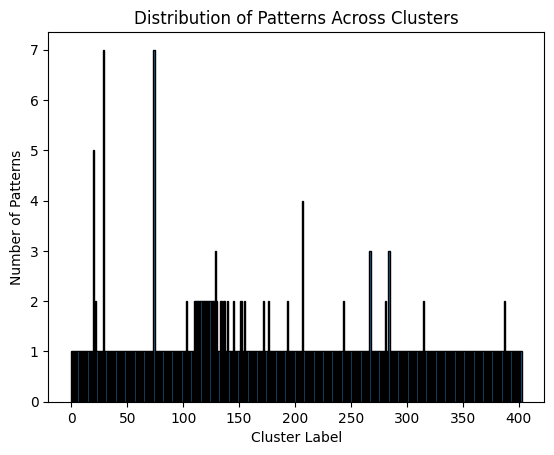

In [32]:
from matplotlib import pyplot as plt
plt.hist(labels, bins=np.arange(labels.min(), labels.max()+2)-0.5, edgecolor='black')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Patterns')
plt.title('Distribution of Patterns Across Clusters')
plt.show()

In [19]:
print("Clusters found:", len(set(labels)) - (1 if -1 in labels else 0))

Clusters found: 18


In [12]:
new_data = data["Pattern Name"]
new_data = new_data.to_frame()

In [13]:
new_data

,Pattern Name
0,LLM-Augmented Knowledge Base
1,LLM as Semantic Content Encoder
2,Instruction Tuning for Recommendation
3,LLM as Explainable Recommender
4,LLM as Direct Recommender (via In-Context Lear...
...,...
215,Reasoning Verification (Entailer)
216,Monte-Carlo Planning for Faithful Reasoning (F...
217,Retrieval-Augmented Reasoning
218,LLM as a Semantic Parser


In [14]:
new_data["cluster"]= labels

In [15]:
type(new_data)

pandas.core.frame.DataFrame

In [16]:
type(data)

pandas.core.frame.DataFrame

In [17]:
new_data

,Pattern Name,cluster
0,LLM-Augmented Knowledge Base,0
1,LLM as Semantic Content Encoder,0
2,Instruction Tuning for Recommendation,0
3,LLM as Explainable Recommender,0
4,LLM as Direct Recommender (via In-Context Lear...,0
...,...,...
215,Reasoning Verification (Entailer),0
216,Monte-Carlo Planning for Faithful Reasoning (F...,0
217,Retrieval-Augmented Reasoning,0
218,LLM as a Semantic Parser,0


In [27]:
num_clusters = len(set(labels))
new_data.to_json(f"/home/hasinthaka/Documents/Projects/AI/AI Pattern Mining/Paper Mining/outputs/[25.09.12] - 02 - Prompt, Temperature, Embedding Model, Clustering changes/patterns_with_{num_clusters}_clusters.json",index=False,indent=4,orient="records")

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

In [36]:
reduced[0]

array([-0.06855733, -0.0602404 ])

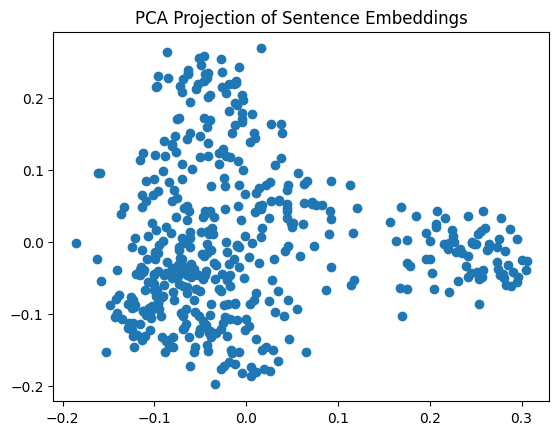

In [34]:
import matplotlib.pyplot as plt

plt.scatter(reduced[:, 0], reduced[:, 1])
plt.title("PCA Projection of Sentence Embeddings")
plt.show()